# Tarea 3. Aprendizaje no supervisado

En este notebook se aplica aprendizaje no supervisado para identificar perfiles de estudiantes a partir de las variables disponibles del dataset.  


## 1. Importación de librerías

Se importan las librerías necesarias para cargar los datos, preprocesarlos, aplicar clustering con K-Means, reducir la dimensionalidad con PCA y evaluar la calidad de los clusters mediante el coeficiente de silueta.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

## 2. Carga de datos y separación de variables

Se carga el dataset y se elimina la variable `objetivo` del conjunto de variables usadas para formar los clusters.  
Esto es importante porque el objetivo del aprendizaje no supervisado es encontrar agrupaciones sin utilizar etiquetas conocidas.

Después se identifican las variables numéricas y categóricas para aplicar a cada tipo de variable el preprocesado adecuado.

In [2]:
df = pd.read_csv("rendimiento_estudiantes.csv", sep=";")

X = df.drop(columns=["objetivo"], errors="ignore")

print("Número de variables usadas:", X.shape[1])

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas:", len(cat_cols))
print("Variables numéricas:", len(num_cols))

Número de variables usadas: 36
Variables categóricas: 17
Variables numéricas: 19


## 3. Preprocesado de los datos

Antes de aplicar K-Means, todas las variables deben estar en formato numérico y en escalas comparables.

- Las variables numéricas se imputan con la mediana y se estandarizan.
- Las variables categóricas se imputan con la categoría más frecuente y se transforman mediante one-hot encoding.


In [3]:
# Preprocesado para variables numéricas:
# - imputación con la mediana
# - estandarización para que todas las variables tengan una escala comparable
transformar_numericas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesado para variables categóricas:
# - imputación con la categoría más frecuente
# - codificación one-hot para transformar categorías en variables numéricas
transformar_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", transformar_numericas, num_cols),
    ("cat", transformar_categoricas, cat_cols)
])

X_preprocesado = preprocessor.fit_transform(X)

print("Dimensiones tras el preprocesado:", X_preprocesado.shape)

Dimensiones tras el preprocesado: (4424, 255)


## 4. Elección del número de clusters

Para elegir el número de clusters se calcula el coeficiente de silueta medio para distintos valores de `k`.

El coeficiente de silueta mide hasta qué punto cada observación está bien asignada a su cluster:
- valores cercanos a 1 indican clusters bien separados;
- valores cercanos a 0 indican solapamiento;
- valores negativos indican posibles asignaciones incorrectas.

Se prueba `k` entre 2 y 6 y se selecciona el valor con mejor silhouette score.


Silhouette score por número de clusters:
  k = 2: 0.2087
  k = 3: 0.2295
  k = 4: 0.1543
  k = 5: 0.0905
  k = 6: 0.0835

Mejor número de clusters según silueta: 3


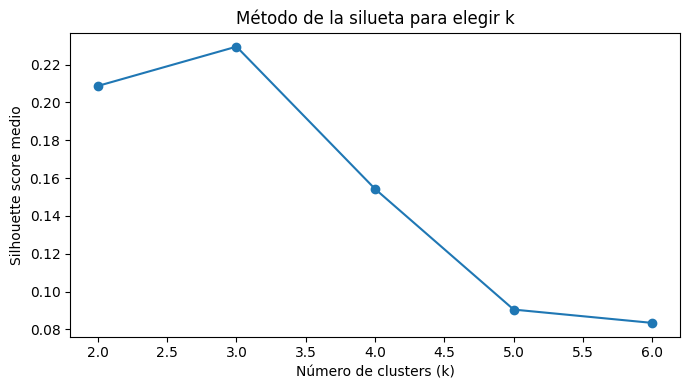

In [4]:
k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(X_preprocesado)
    score = silhouette_score(X_preprocesado, labels_tmp)
    silhouette_scores.append(score)

best_k = list(k_values)[np.argmax(silhouette_scores)]

print("\nSilhouette score por número de clusters:")
for k, score in zip(k_values, silhouette_scores):
    print(f"  k = {k}: {score:.4f}")

print(f"\nMejor número de clusters según silueta: {best_k}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score medio")
plt.title("Método de la silueta para elegir k")
plt.tight_layout()
plt.show()

## 5. Entrenamiento del modelo final

Una vez elegido el número óptimo de clusters, se entrena el modelo K-Means final con ese valor de `k`.  
También se calcula el silhouette score final para resumir la calidad global de la agrupación.

In [5]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_preprocesado)

silhouette_avg = silhouette_score(X_preprocesado, clusters)
print(f"\nSilhouette score final (k={best_k}): {silhouette_avg:.4f}")


Silhouette score final (k=3): 0.2295


## 6. Visualización con PCA

PCA se utiliza únicamente como herramienta de visualización.  
El clustering se ha realizado en el espacio completo de variables preprocesadas, pero PCA permite proyectar los datos a dos dimensiones para representar gráficamente los grupos.


Varianza explicada — PC1: 23.40%, PC2: 9.74%
Varianza acumulada (2 componentes): 33.14%
NOTA: solo el 33% de la información es visible en 2D.


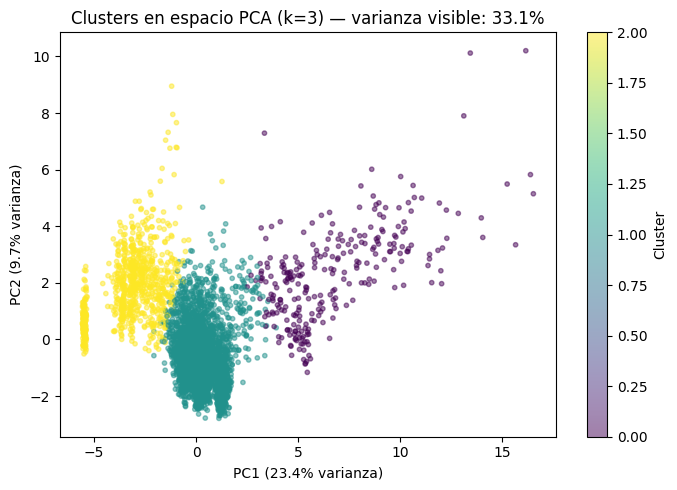

In [8]:
# PCA se utiliza solo para visualizar los clusters en 2D.
# El clustering se ha realizado usando todo el espacio preprocesado.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_preprocesado)

var_exp = pca.explained_variance_ratio_

print(f"\nVarianza explicada — PC1: {var_exp[0]:.2%}, PC2: {var_exp[1]:.2%}")
print(f"Varianza acumulada (2 componentes): {var_exp.sum():.2%}")
print("NOTA: solo el {:.0%} de la información es visible en 2D.".format(var_exp.sum()))

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, alpha=0.5, s=10)
plt.xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
plt.ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
plt.title(f"Clusters en espacio PCA (k={best_k}) — varianza visible: {var_exp.sum():.1%}")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

## 8. Gráfico de silueta por individuo

El gráfico de silueta permite analizar la calidad de asignación de cada observación individual.  
Cada barra representa el coeficiente de silueta de un estudiante. Clusters con muchas observaciones cerca de 0 indican mayor solapamiento con otros grupos.

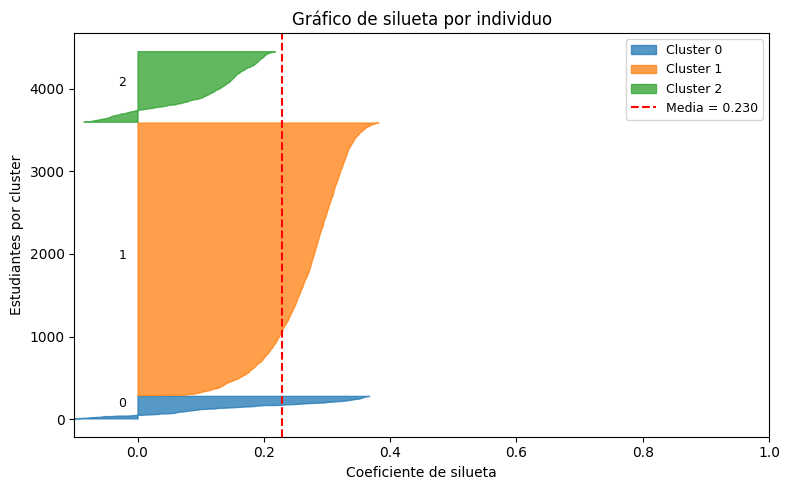

In [9]:
sample_silhouette_values = silhouette_samples(X_preprocesado, clusters)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10.colors

for i in range(best_k):
    ith_vals = np.sort(sample_silhouette_values[clusters == i])
    y_upper = y_lower + len(ith_vals)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_vals,
        alpha=0.75,
        color=colors[i],
        label=f"Cluster {i}"
    )
    ax.text(-0.03, y_lower + 0.5 * len(ith_vals), str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(
    x=silhouette_avg,
    color="red",
    linestyle="--",
    label=f"Media = {silhouette_avg:.3f}"
)
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Estudiantes por cluster")
ax.set_title("Gráfico de silueta por individuo")
ax.set_xlim(-0.1, 1)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Análisis inicial de los clusters

Una vez asignado un cluster a cada estudiante, se analiza el tamaño de cada grupo y se cruza con la variable `objetivo`.

Aunque `objetivo` no se ha utilizado para entrenar el modelo, esta comparación permite interpretar si los clusters están relacionados con abandono, matriculado o graduado.

In [10]:
df_clusters = df.copy()
df_clusters["cluster"] = clusters

print("\nTamaño de cada cluster:")
print(df_clusters["cluster"].value_counts().sort_index())

print("\nDistribución de 'objetivo' dentro de cada cluster (%):")
tabla_objetivo = pd.crosstab(
    df_clusters["cluster"],
    df_clusters["objetivo"],
    normalize="index"
) * 100

print(tabla_objetivo.round(2))


Tamaño de cada cluster:
cluster
0     273
1    3297
2     854
Name: count, dtype: int64

Distribución de 'objetivo' dentro de cada cluster (%):
objetivo  abandono  graduado  matriculado
cluster                                  
0            23.81     63.00        13.19
1            19.84     59.48        20.69
2            82.20      8.90         8.90


## 10. Perfil de cada cluster

Para interpretar los grupos, se calculan medias de variables numéricas relevantes y distribuciones de variables categóricas.

El heatmap muestra, mediante colores, qué clusters están por encima o por debajo de la media relativa en cada variable.  
Las anotaciones muestran los valores medios reales, lo que facilita la interpretación sustantiva de cada perfil.

In [14]:
variables_numericas_perfil = [
    "nota_media_1sem",
    "nota_media_2sem",
    "nota_admision",
    "asignaturas_1sem_aprobadas",
    "edad_al_matricularse",
]

variables_categoricas_perfil = [
    "matricula_al_dia",
    "becado"
]

# Nos quedamos solo con las variables que realmente existen en el dataset.
variables_numericas_perfil = [v for v in variables_numericas_perfil if v in df_clusters.columns]
variables_categoricas_perfil = [v for v in variables_categoricas_perfil if v in df_clusters.columns]

print("\nPerfil medio de cada cluster (variables numéricas):")
perfil = df_clusters.groupby("cluster")[variables_numericas_perfil].mean().round(2)
print(perfil)




Perfil medio de cada cluster (variables numéricas):
         nota_media_1sem  nota_media_2sem  nota_admision  \
cluster                                                    
0                  12.66            12.67         129.47   
1                  12.74            12.52         126.81   
2                   1.91             0.59         126.83   

         asignaturas_1sem_aprobadas  edad_al_matricularse  
cluster                                                    
0                             11.70                 28.70  
1                              5.26                 22.10  
2                              0.35                 26.03  


## 11. Variable categórica adicional: beca

Por último, se muestra de forma específica la distribución de la variable `becado` por cluster, ya que puede ayudar a interpretar diferencias socioeconómicas entre grupos de estudiantes.

In [16]:
if "becado" in df_clusters.columns:
    print("\nDistribución de 'becado' por cluster (%):")
    tabla_becado = pd.crosstab(
        df_clusters["cluster"],
        df_clusters["becado"],
        normalize="index"
    ) * 100
    print(tabla_becado.round(2))


Distribución de 'becado' por cluster (%):
becado      no     si
cluster              
0        88.28  11.72
1        70.25  29.75
2        89.93  10.07


## 12. Conclusión

Este análisis permite identificar perfiles de estudiantes sin utilizar directamente la variable objetivo.  
La interpretación posterior de los clusters ayuda a detectar grupos con mayor riesgo de abandono, perfiles mayoritarios y posibles diferencias asociadas al rendimiento académico, la edad, la situación administrativa o la beca.
